In [2]:
import subprocess
subprocess.run(["pip", "install", "--user", "pandas", "matplotlib", "seaborn", "openpyxl"], check=True)

CompletedProcess(args=['pip', 'install', '--user', 'pandas', 'matplotlib', 'seaborn', 'openpyxl'], returncode=0)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data.csv', encoding='latin-1')

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic stats:")
df.describe()

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Data types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Basic stats:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
# Remove rows with missing CustomerID and Description
df_clean = df.dropna(subset=['CustomerID', 'Description'])

# Remove cancelled orders (negative quantity) and bad prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Convert InvoiceDate to proper datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create a Revenue column (Quantity x UnitPrice)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Confirm the cleaned shape
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original shape: (541909, 8)
Cleaned shape: (397884, 9)
Rows removed: 144025


C:\Users\asus\AppData\Local\Temp\ipykernel_44720\3562482189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')


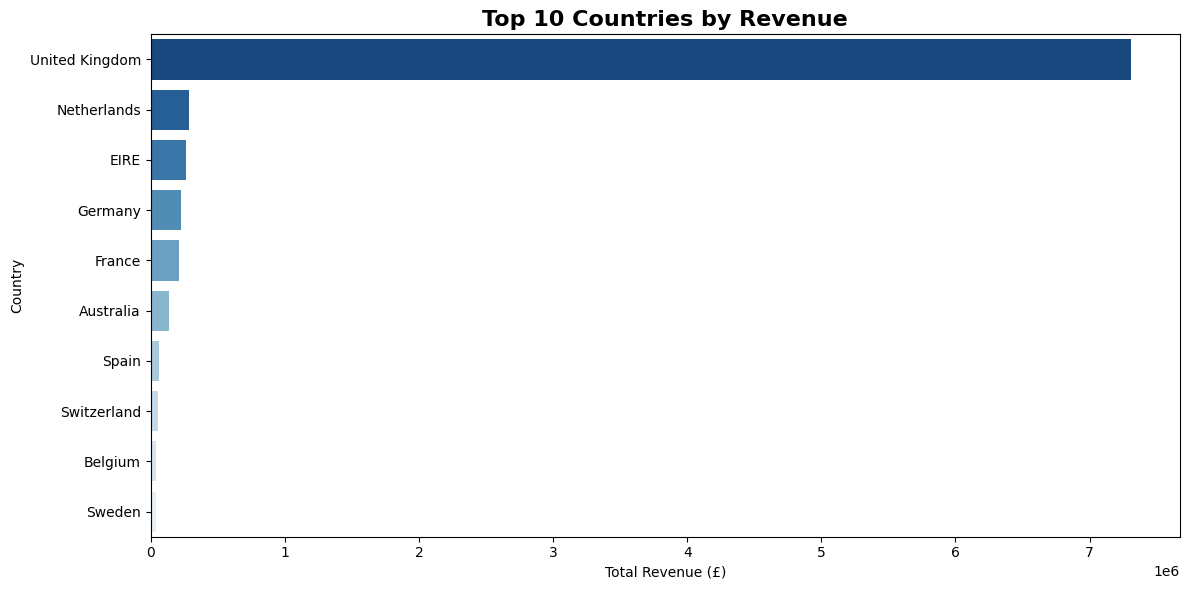

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [7]:
# ---- ANALYSIS 1: Revenue by Country (Top 10) ----
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='Blues_r')
plt.title('Top 10 Countries by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart1_revenue_by_country.png', dpi=150)
plt.show()
print(country_revenue)

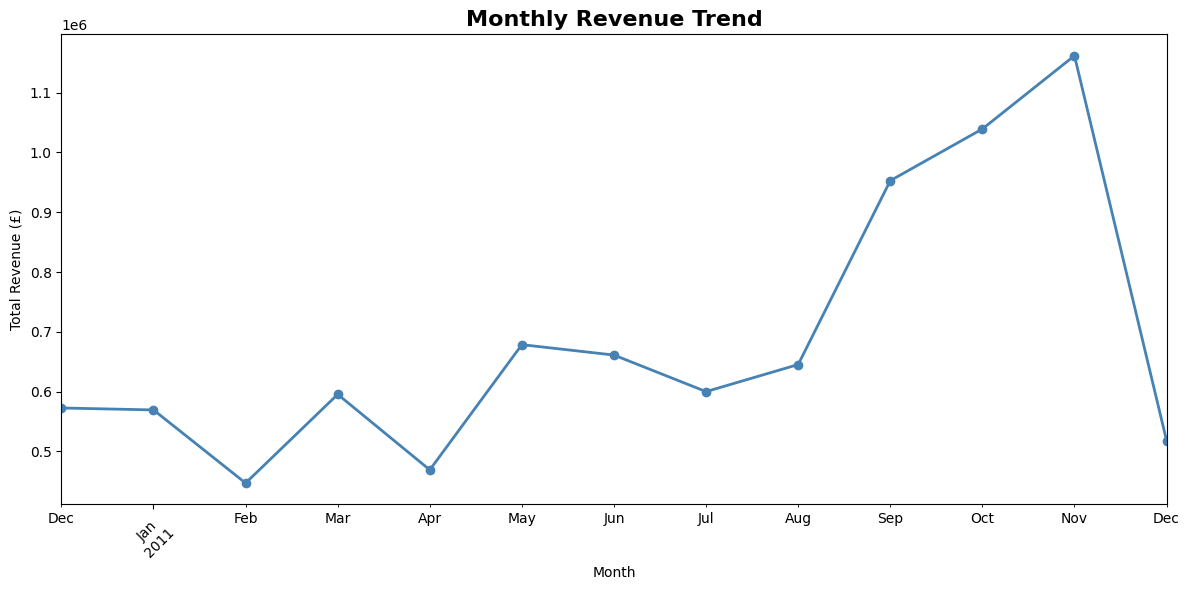

In [8]:
# ---- ANALYSIS 2: Monthly Revenue Trend ----
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_monthly_revenue.png', dpi=150)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_44720\1110519623.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')


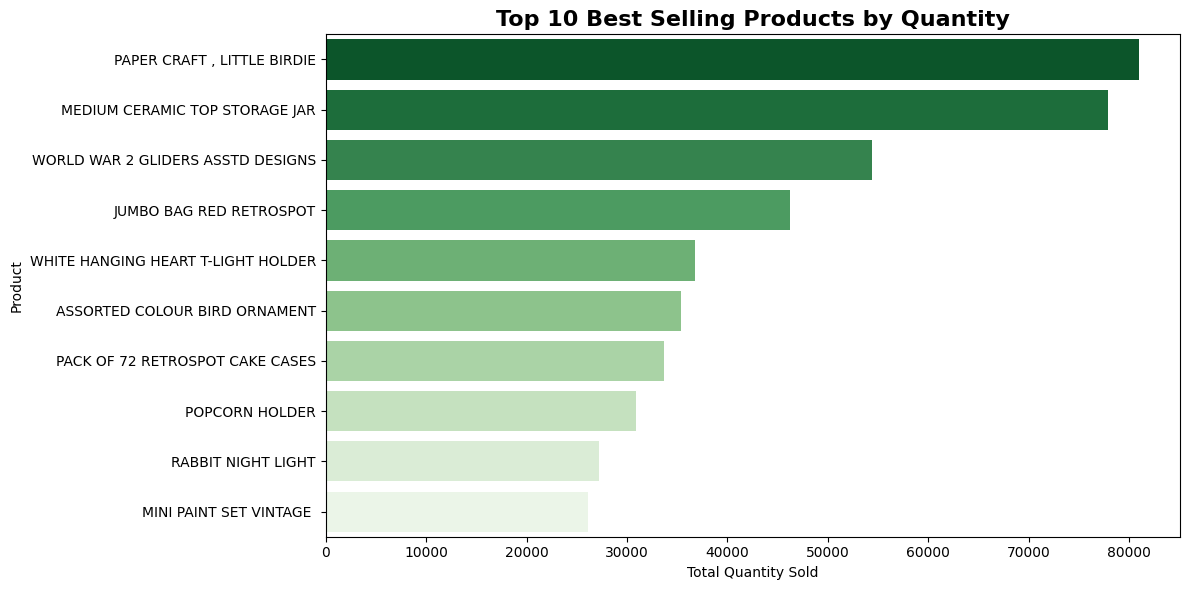

In [9]:
# ---- ANALYSIS 3: Top 10 Best Selling Products ----
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Greens_r')
plt.title('Top 10 Best Selling Products by Quantity', fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('chart3_top_products.png', dpi=150)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_44720\1948495378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_revenue.index, y=hourly_revenue.values, palette='Oranges_r')


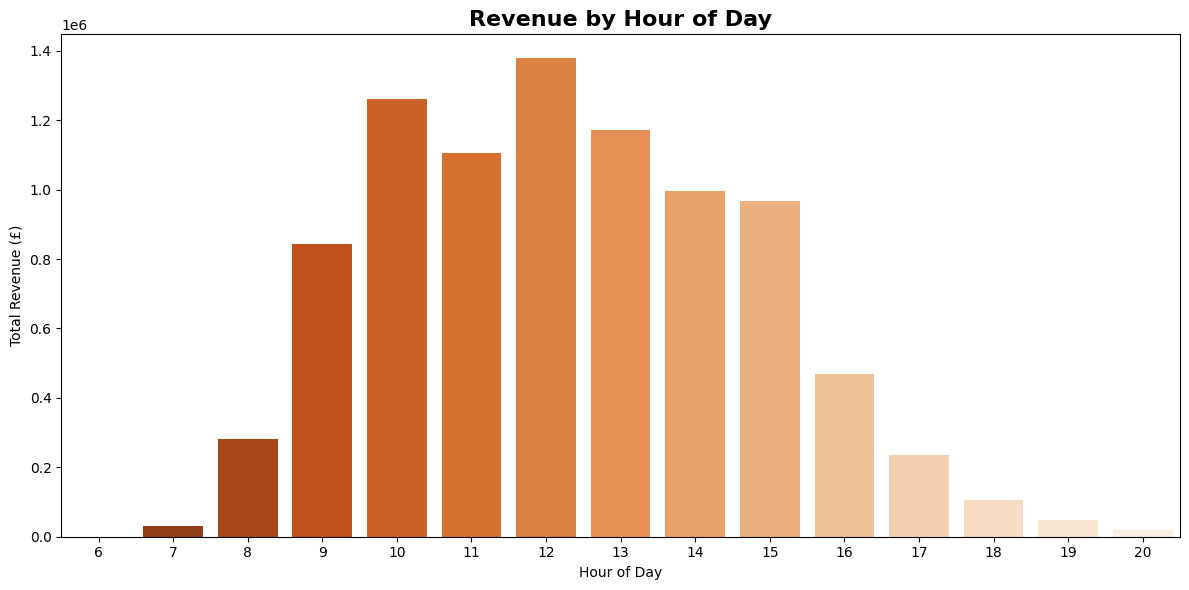

In [10]:
# ---- ANALYSIS 4: Revenue by Hour of Day ----
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hourly_revenue = df_clean.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_revenue.index, y=hourly_revenue.values, palette='Oranges_r')
plt.title('Revenue by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('chart4_revenue_by_hour.png', dpi=150)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_44720\4047485365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='Purples_r')


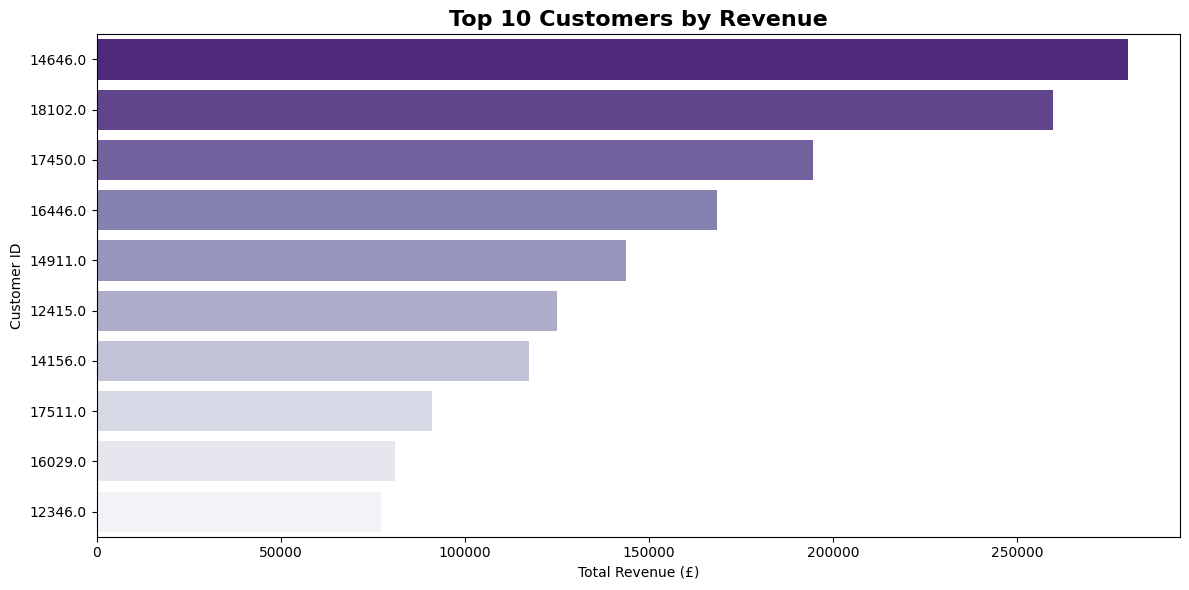

In [11]:
# ---- ANALYSIS 5: Top 10 Customers by Revenue ----
top_customers = df_clean.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='Purples_r')
plt.title('Top 10 Customers by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.savefig('chart5_top_customers.png', dpi=150)
plt.show()